# Notebook 6: Model Evaluation & Sales Forecasting

**Project:** End-to-End Retail Sales Analytics and Forecasting using Python, Machine Learning, and Power BI

This notebook loads the trained model, evaluates its performance, creates forecast visualizations, and exports forecast results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import cross_val_score

plt.style.use("ggplot")

model = joblib.load("sales_model.pkl")

df = pd.read_csv("feature_engineered_retail_sales.csv", parse_dates=["Order_Date","Ship_Date"])
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Weekday,Is_Weekend,Sales_per_Quantity,Profit_Margin,Order_Week,Day_of_Week,Shipping_Days,Discount_Flag,Customer_Order_Count,Product_Order_Count
0,1,CA-2016-152156,2016-11-08,2016-11-11,2,CG-12520,Claire Gute,0,United States,194,...,Tuesday,0,130.9800,16.00,45,Tuesday,3,0,5,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,2,CG-12520,Claire Gute,0,United States,194,...,Tuesday,0,243.9800,30.00,45,Tuesday,3,0,5,12
2,3,CA-2016-138688,2016-06-12,2016-06-16,2,DV-13045,Darrin Van Huff,1,United States,266,...,Sunday,1,7.3100,47.00,23,Sunday,4,0,9,7
3,4,US-2015-108966,2015-10-11,2015-10-18,3,SO-20335,Sean O'Donnell,0,United States,153,...,Sunday,1,191.5155,-40.00,41,Sunday,7,1,15,8
4,5,US-2015-108966,2015-10-11,2015-10-18,3,SO-20335,Sean O'Donnell,0,United States,153,...,Sunday,1,11.1840,11.25,41,Sunday,7,1,15,5


In [2]:
target="Sales"

drop_cols=[target,"Order_ID","Customer_Name","Product_Name"]
X=df.drop(columns=[c for c in drop_cols if c in df.columns])
y=df[target]

predictions=model.predict(X)

results=pd.DataFrame({
    "Actual_Sales":y,
    "Predicted_Sales":predictions
})

results["Residual"]=results["Actual_Sales"]-results["Predicted_Sales"]
results.head()

,Actual_Sales,Predicted_Sales,Residual
0,261.9600,372.778489,-110.818489
1,731.9400,857.968774,-126.028774
2,14.6200,-75.783823,90.403823
3,957.5775,601.531951,356.045549
4,22.3680,-42.262459,64.630459


In [3]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae=mean_absolute_error(y,predictions)
rmse=np.sqrt(mean_squared_error(y,predictions))
r2=r2_score(y,predictions)

print("MAE :",mae)
print("RMSE:",rmse)
print("R2  :",r2)

MAE : 106.16904277956993
RMSE: 257.3791018473849
R2  : 0.8294419297697037


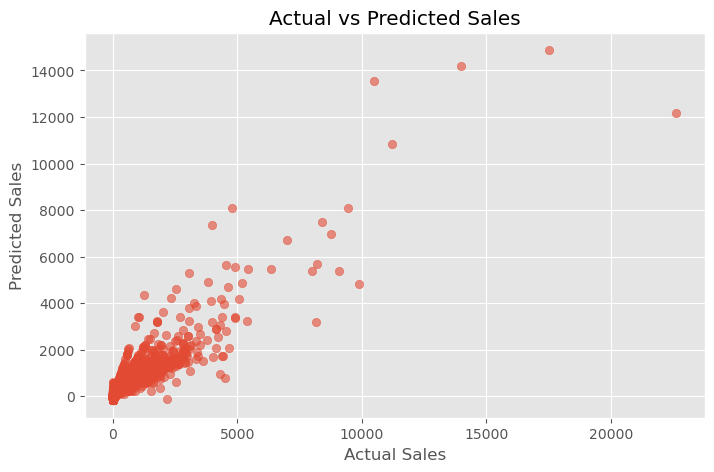

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(results["Actual_Sales"],results["Predicted_Sales"],alpha=0.6)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

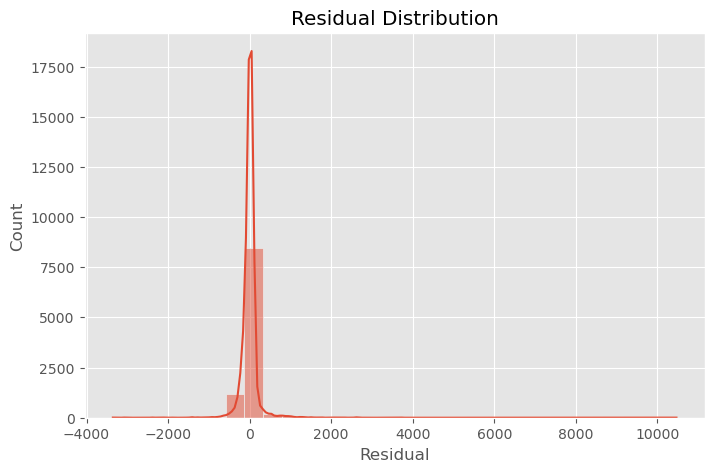

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(results["Residual"],bins=30,kde=True)
plt.title("Residual Distribution")
plt.show()

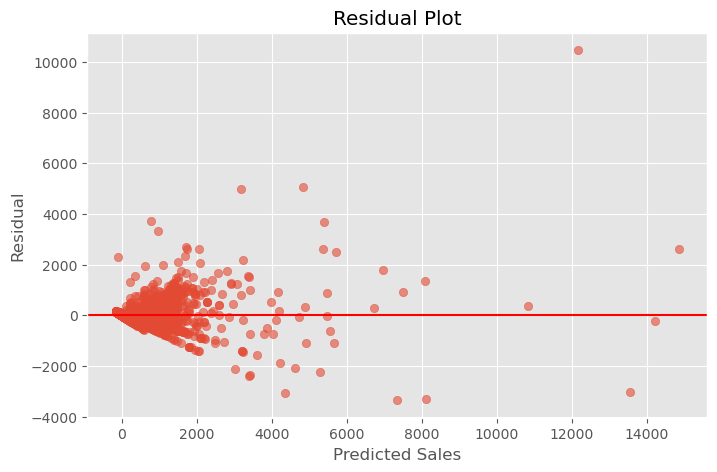

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(results["Predicted_Sales"],results["Residual"],alpha=0.6)
plt.axhline(0,color="red")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [7]:
# Cross-validation (if supported)
try:
    scores=cross_val_score(model,X,y,cv=5,scoring="r2")
    print("Cross Validation R2 Scores:",scores)
    print("Average R2:",scores.mean())
except Exception as e:
    print("Cross-validation skipped:",e)

Cross Validation R2 Scores: [0.78099956 0.82397466 0.79626616 0.87175572 0.82721281]
Average R2: 0.8200417808392585


In [8]:
# Feature Importance (Tree-based models only)
try:
    feature_names=model.named_steps["preprocessor"].get_feature_names_out()
    importance=model.named_steps["model"].feature_importances_

    fi=(pd.DataFrame({
        "Feature":feature_names,
        "Importance":importance
    })
    .sort_values("Importance",ascending=False)
    .head(20))

    plt.figure(figsize=(10,6))
    plt.barh(fi["Feature"],fi["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Top 20 Important Features")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Feature importance not available:",e)

Feature importance not available: 'LinearRegression' object has no attribute 'feature_importances_'


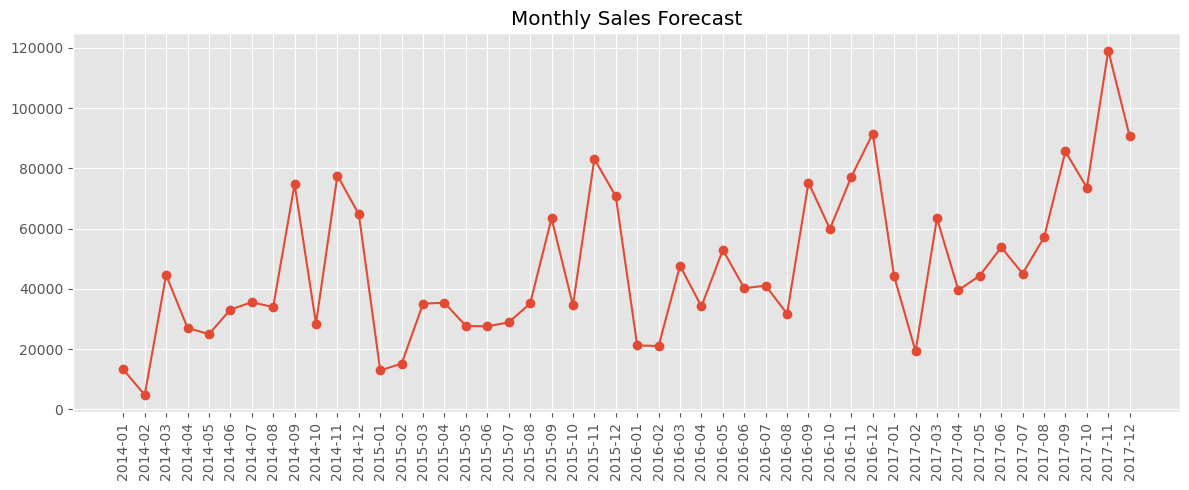

In [9]:
# Monthly Forecast
forecast=df.copy()
forecast["Predicted_Sales"]=predictions

monthly=forecast.groupby(forecast["Order_Date"].dt.to_period("M"))["Predicted_Sales"].sum()
monthly.index=monthly.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly.index,monthly.values,marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales Forecast")
plt.tight_layout()
plt.show()

In [10]:
results.to_csv("final_sales_forecast.csv",index=False)

summary=pd.DataFrame({
    "Metric":["MAE","RMSE","R2"],
    "Value":[mae,rmse,r2]
})

summary.to_csv("model_evaluation_summary.csv",index=False)

print("Forecast and evaluation reports exported successfully.")

Forecast and evaluation reports exported successfully.
